# Actividad 1 - Encapsulamiento en un Equipo de Futbol

Este notebook muestra como proteger las estadisticas de un equipo con encapsulamiento.

## Objetivo 

1. Evitar modificacion directa de atributos criticos.
2. Mantener consistencia al registrar resultados.
3. Exponer solo metodos publicos controlados.

In [1]:
class Equipo:
    def __init__(self, nombre: str, ciudad: str) -> None:
        self.nombre: str = nombre
        self.ciudad: str = ciudad
        self.__partidos_jugados: int = 0
        self.__partidos_ganados: int = 0
        self.__partidos_empatados: int = 0
        self.__partidos_perdidos: int = 0
        self.__goles_favor: int = 0
        self.__goles_contra: int = 0
        self.__puntos: int = 0

    def registrar_partido(self, goles_favor: int, goles_contra: int) -> bool:
        if goles_favor < 0 or goles_contra < 0:
            return False

        self.__partidos_jugados += 1
        self.__goles_favor += goles_favor
        self.__goles_contra += goles_contra

        if goles_favor > goles_contra:
            self.__partidos_ganados += 1
            self.__puntos += 3
        elif goles_favor == goles_contra:
            self.__partidos_empatados += 1
            self.__puntos += 1
        else:
            self.__partidos_perdidos += 1

        return True

    def diferencia_gol(self) -> int:
        return self.__goles_favor - self.__goles_contra

    def resumen_estadisticas(self) -> str:
        return (
            f"{self.nombre} ({self.ciudad}) - PJ: {self.__partidos_jugados}, "
            f"PG: {self.__partidos_ganados}, PE: {self.__partidos_empatados}, "
            f"PP: {self.__partidos_perdidos}, GF: {self.__goles_favor}, "
            f"GC: {self.__goles_contra}, DG: {self.diferencia_gol()}, "
            f"Pts: {self.__puntos}"
        )

    def obtener_puntos(self) -> int:
        return self.__puntos

In [2]:
equipo = Equipo(nombre="Halcones FC", ciudad="Bogota")

assert equipo.registrar_partido(2, 0) is True
assert equipo.registrar_partido(1, 1) is True
assert equipo.registrar_partido(0, 3) is True
assert equipo.registrar_partido(-1, 2) is False

print(equipo.resumen_estadisticas())
assert equipo.obtener_puntos() == 4
assert equipo.diferencia_gol() == -1

try:
    equipo.__puntos
    raise AssertionError("El atributo privado no deberia ser accesible")
except AttributeError:
    print("Acceso directo bloqueado correctamente")

assert equipo._Equipo__puntos == 4
print("Encapsulamiento verificado")

Halcones FC (Bogota) - PJ: 3, PG: 1, PE: 1, PP: 1, GF: 3, GC: 4, DG: -1, Pts: 4
Acceso directo bloqueado correctamente
Encapsulamiento verificado


## Por que aqui usamos encapsulamiento

- Porque los datos sensibles (puntos y estadisticas) no deben alterarse libremente.
- Porque las reglas del dominio se aplican dentro de metodos controlados.
- Porque esto reduce errores y mantiene coherencia en la tabla.

## Diagrama PlantUML 
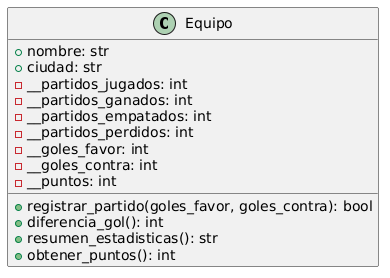